This notebook includes the second version of the validation of `cloelib` against `CosmoSIS` at the power spectra level. Since the structure of the codes is different, `CosmoSIS` is computed outside from this notebook and here we just read and compare its output. Some new features can be found w.r.t. the first validation:

- Validation of all bin pairs for all probes (WL, GC, GGL).
- Validation of both full-sky and pseudo-Cls.

 As a first test, we implement a simple configuration consisting of:
-  6 redshift bins 
-  Synthetic redshift distributions
-  Constant galaxy bias b=1 for all bins
-  No IA, no magnification

Further test such as real data n(z), different galaxy bias and NLA IA have also been validated.

CosmoSIS data can be downloaded from Zenodo: https://zenodo.org/records/17510519

In [142]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
from copy import deepcopy
import os
import time
import astropy.io.fits as fits
from scipy import interpolate

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
import euclidlib as el

import pyccl as ccl

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

In [143]:
# Plot settings
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.subplot.left'] = 0.125
plt.rcParams['figure.subplot.right'] = 0.9
plt.rcParams['figure.subplot.bottom'] = 0.125
plt.rcParams['figure.subplot.top'] = 0.9
plt.rcParams['axes.labelsize'] = 28
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.labelsize'] = 17
plt.rcParams['ytick.labelsize'] = 17
plt.rcParams['xtick.major.pad'] = 6.
plt.rcParams['xtick.minor.pad'] = 6.
plt.rcParams['ytick.major.pad'] = 6.
plt.rcParams['ytick.minor.pad'] = 6.
plt.rcParams['xtick.major.size'] = 6. # major tick size in points
plt.rcParams['xtick.minor.size'] = 3. # minor tick size in points
plt.rcParams['ytick.major.size'] = 6. # major tick size in points
plt.rcParams['ytick.minor.size'] = 3. # minor tick size in points
# plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] =  'serif'
# plt.rcParams['font.family'] =  'cmr10'
plt.rcParams['font.size'] = 2 
# axes linewidth
plt.rcParams['axes.linewidth'] = 2.0 #set the value globally

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

## 1. Matter power spectra
As `cloelib` and `CosmoSIS` call `HMCode2020Emu` internally, we want to check the interfaces of both codes give the same results.

### 1.1. `CosmoSIS`

In [144]:
# Local path to CosmoSIS output files
path_cosmosis = './cosmosis_data/'

# Read and convert to non-Hubble units.
z_cosmosis = np.loadtxt(path_cosmosis + 'cells/matter_power_nl/z.txt')
k_nonlin_cosmosis = np.loadtxt(path_cosmosis + 'cells/matter_power_nl/k_h.txt')*(67./100)
pk_nonlin_cosmosis = np.zeros((4, len(k_nonlin_cosmosis)))

# ComoSIS P(k) are computed in all the z-range. Let's pick some
for i in range(4):
    z_argmin = np.argmin(np.abs(z_cosmosis-i)) 
    print(z_cosmosis[z_argmin])
    pk_nonlin_cosmosis[i, :] = np.loadtxt(path_cosmosis + 'cells/matter_power_nl/p_k.txt')[z_argmin]/(67./100)**3

1e-06
0.9979966593186373
2.002004340681363
3.0


### 1.2. `cloelib` 

In [145]:
background = CAMBBackground(H0 = 67., 
                            Omega_cdm0 = 0.27, 
                            Omega_b0 = 0.049, 
                            w0 = -1, 
                            wa = 0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.06,
                            N_mnu = 1,                          
                            gamma_MG=0
                            )

# Define redshift (z) and wavenumber (k) ranges to compute perturbations
zs = np.linspace(1e-6, 3., 500) 
kmin = 5e-4
kmax = 50
nk = 400
ks = np.logspace(np.log10(kmin), np.log10(kmax), nk)

linear_perturbations = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations = HMemuNonLinearPerturbations(background, linear_perturbations, zs, log10TAGN=7.8)

# Save some P(k) to compare with CosmoSIS
pk_nonlin_cloe =  np.zeros((4, len(ks)))
z_pos = [1e-06, 0.9979966593186373, 2.002004340681363, 3.0]
for i in range(4):
    pk_nonlin_cloe[i,:] = nonlinear_perturbations.matter_power_spectrum(z_pos[i], ks)[0]

### 1.3. Compare power spectra

$\% \: \rm{diff.} = \frac{P_A(k)-P_B(k)}{P_B(k)} \times 100$

In [146]:
# Interpolate both P(k) to same k-array to compute ratios
k_interp = np.logspace(np.log10(np.max((ks[0], k_nonlin_cosmosis[0]))), np.log10(np.min((ks[-1], k_nonlin_cosmosis[-1]))), nk)

pk_nonlin_cloe_interp = np.zeros((4, nk))
pk_nonlin_cosmosis_interp = np.zeros((4, nk))
for i in range(4):
    pk_nonlin_cloe_interp[i] = np.interp(k_interp, ks, pk_nonlin_cloe[i])
    pk_nonlin_cosmosis_interp[i] = np.interp(k_interp, k_nonlin_cosmosis, pk_nonlin_cosmosis[i])

/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/1487610369.py:14: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs.set_xlim([0, 100])


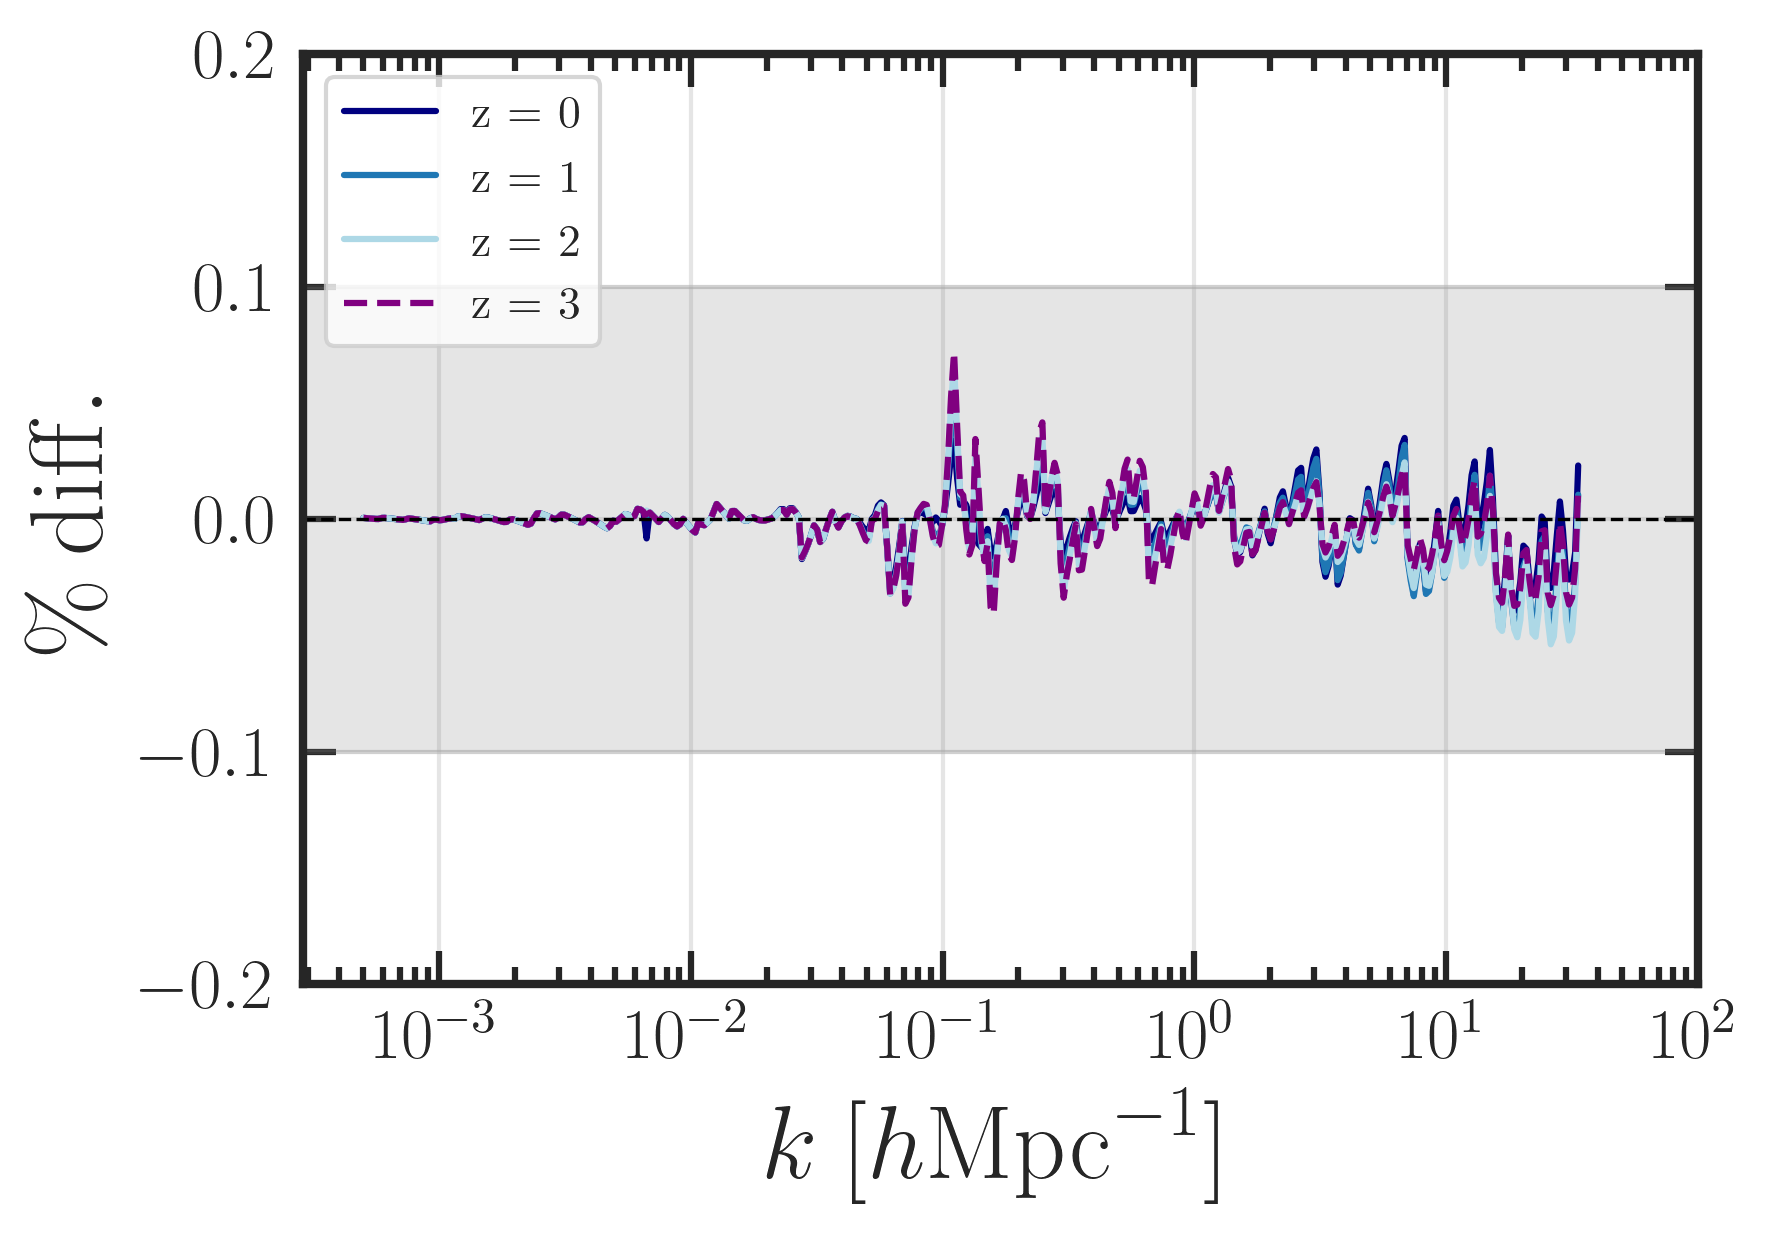

In [147]:
fig, axs = plt.subplots(1, 1, figsize=(6,4))
colors = ['navy', 'tab:blue', 'lightblue', 'purple']
ls = ['-', '-', '-', '--']

# Ratios
axs.set_xlabel(r'$k\: [h\rm{Mpc}^{-1}]$', fontsize=25)
axs.set_ylabel(r'$\%\:\rm{diff.}$', fontsize=25)   
for i in range(4):
    axs.plot(k_interp, (pk_nonlin_cloe_interp[i] - pk_nonlin_cosmosis_interp[i])/pk_nonlin_cloe_interp[i]*100, ls=ls[i], color = colors[i], label='z = %s'%i)

axs.legend(loc='upper left')
axs.set_xscale('log')
axs.set_ylim([-.2, .2])
axs.set_xlim([0, 100])
axs.axhline(0, 0, 30.0, lw=.8, ls='--', color='black')
axs.fill_between(np.linspace(0, 1000, 10), -.1, .1, alpha=.2, color='grey')

axs.tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
axs.tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
axs.grid(alpha=0.5)

## 2. Redshift distributions

In [158]:
# Read with euclidlib
z, nz_heracles = el.photo.redshift_distributions(path_cosmosis + 'nz_example.fits')

# Normalise dndz
dndz_pos_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_pos_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)

dndz_she_norm = deepcopy(nz_heracles)
for key in nz_heracles.keys():
    dndz_she_norm[key] = nz_heracles[key] / integrate.trapezoid(
                        nz_heracles[key], z)


# Resampling the normalized n(z) with len(zs)=256 values
my_dndz_pos = np.vstack(list(dndz_pos_norm.values()))
dndz_pos = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_pos[i,:] = np.interp(zs, z, my_dndz_pos[i,:])

my_dndz_she = np.vstack(list(dndz_she_norm.values()))
dndz_she = np.zeros([len(nz_heracles.keys()), len(zs)])
for i in range(6):
    dndz_she[i,:] = np.interp(zs, z, my_dndz_she[i,:])

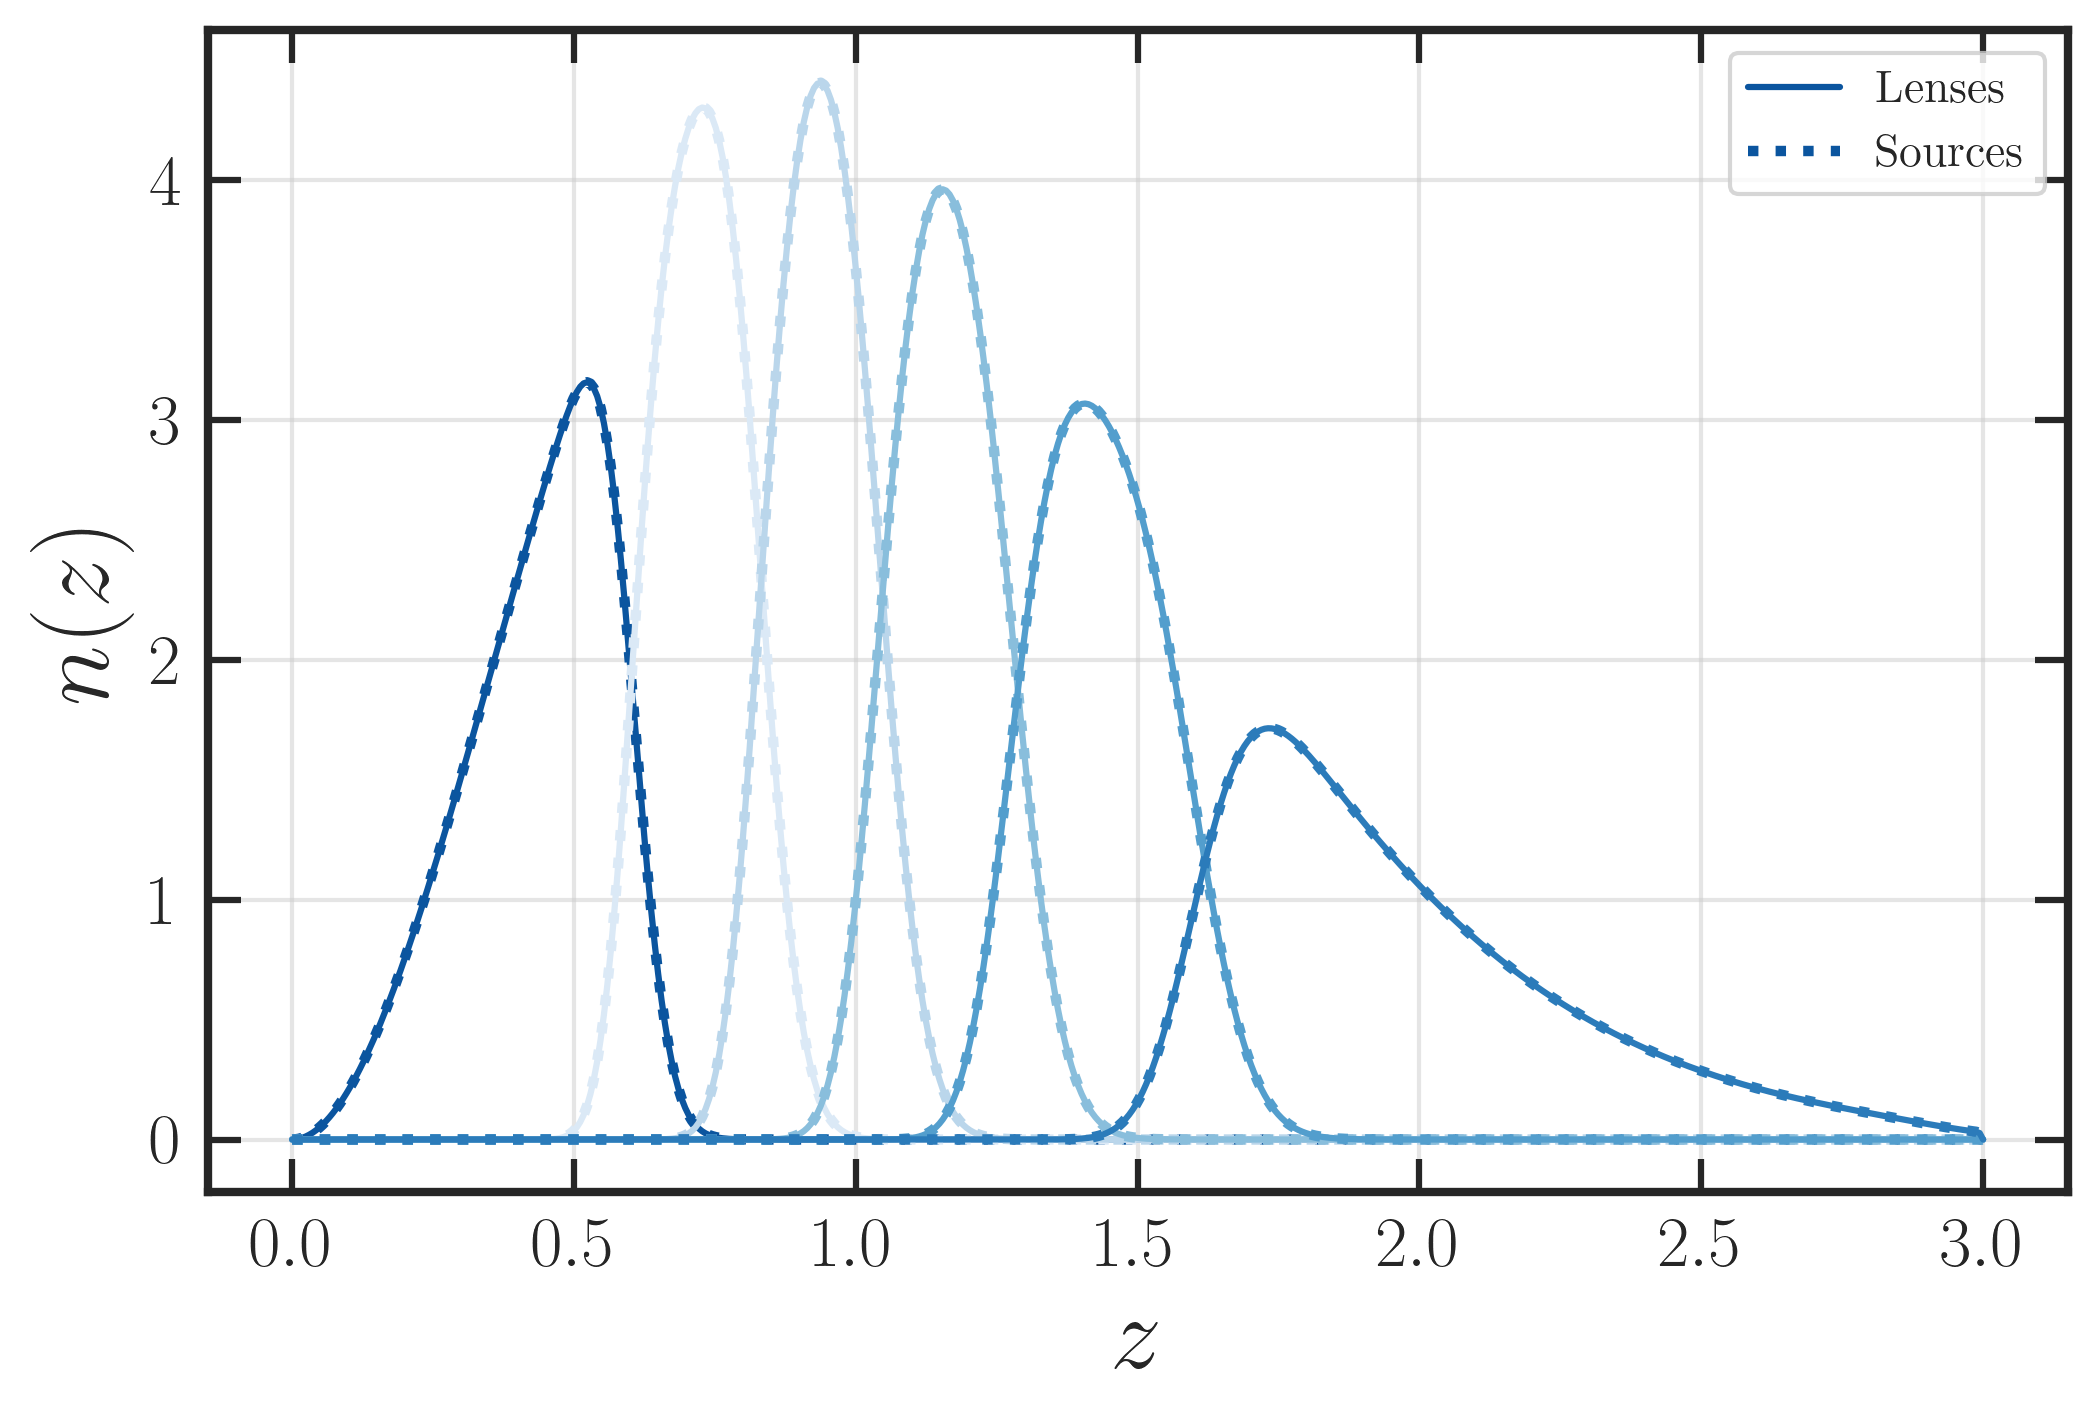

In [149]:
fig, axs = plt.subplots(1, 1, figsize=(8,5))

axs.set_ylabel(r'$n(z)$', fontsize=25)
axs.set_xlabel(r'$z$', fontsize=25)

for i in range(6):
    if i==0:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1], label = r'$\rm{Lenses}$')
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1], label = r'$\rm{Sources}$')

    else:
        axs.plot(zs, dndz_pos[i,:], linewidth=1.5, color=sns.color_palette("Blues", 6)[i-1])
        axs.plot(zs, dndz_she[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1])


axs.tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
axs.tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
axs.grid(alpha=0.5)

axs.legend()

## 3. Full-sky angular spectra

### 3.1. `CosmoSIS`

In [150]:
# COSMOSIS :
ells_cosmosis = np.loadtxt(path_cosmosis + 'cells/shear_cl/ell.txt')
cells_EE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
cells_gg_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
cells_gE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))

# Limber prefactor missing in CosmoSIS
lf_dl=(ells_cosmosis+0.5)**2/np.sqrt((ells_cosmosis+2.)*(ells_cosmosis+1.)*ells_cosmosis*(ells_cosmosis-1.))
for i in range(6):
    for j in range (6):
        if i>=j:
            cells_EE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'cells/shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))*(lf_dl**-2)
            cells_gg_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'cells/galaxy_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))
            cells_gE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'cells/galaxy_shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))*(lf_dl**-1)
        else:
            cells_gE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'cells/galaxy_shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))*(lf_dl**-1)


### 3.2. `cloelib` 

In [151]:
tracer_pos_cloe = PositionsTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_pos,
                            z=zs,
                            galaxy_bias_model='per_bin',
                            nuisance_params={'b1_photo_bin1': 1.0, 'b1_photo_bin2': 1.0, 'b1_photo_bin3': 1.0, 'b1_photo_bin4': 1.0,
                                             'b1_photo_bin5': 1.0, 'b1_photo_bin6': 1.0, 'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                                              'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                                              'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,}

                            )

tracer_she_cloe = ShearTracer(perturbations=nonlinear_perturbations, 
                            dndz=dndz_she,
                            z=zs,
                            nuisance_params={'AIA': 0.0, 'CIA': 0.0, 'EtaIA':0.0, 'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                                              'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                                              'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                                              'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                                              'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                                              'dz_shear_5': 0.0, 'dz_shear_6': 0.0}
                              )  

In [152]:
nl = 32
ells = ells_cosmosis

twopoint_sheshe = AngularTwoPoint(tracer_she_cloe, tracer_she_cloe)
twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
twopoint_posshe = AngularTwoPoint(tracer_she_cloe, tracer_pos_cloe)

cells_EE_cloe = twopoint_sheshe.get_Cl(ells, nl, ks)
cells_gg_cloe = twopoint_pospos.get_Cl(ells, nl, ks)
cells_gE_cloe = twopoint_posshe.get_Cl(ells, nl, ks)

### 3.3. Compare angular power spectra
$\% \:\rm{diff.} = \frac{C_{\rm cloelib}(\ell) - C_{\rm CosmoSIS}(\ell)}{C_{\rm CosmoSIS}(\ell)} \times 100$

Note that the gg and gE signal is null in the low redshift bins, that's why we don't see the the ratio in some bin pairs.

/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/2472892189.py:18: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[i,j].set_xlim([0, 5e3])
/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/2472892189.py:10: RuntimeWarning: divide by zero encountered in divide
  axs[i, j].plot(ells_cosmosis, (cells_gE_cloe[('POS', 'SHE',i+1 , j+1)][0] - cells_gE_cosmosis[:, i, j])/cells_gE_cosmosis[:, i, j]*100, lw=lw, ls='--', color='brown', label='gE cloelib-CosmoSIS', zorder=2)
/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/2472892189.py:9: RuntimeWarning: divide by zero encountered in divide
  axs[i, j].plot(ells_cosmosis, (cells_gg_cloe[('POS', 'POS',j+1 , i+1)][:] - cells_gg_cosmosis[:, i, j])/cells_gg_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:orange', label='gg cloelib-CosmoSIS', zorder=1)
/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/2472892189.py:9: RuntimeWarning: invalid value enco

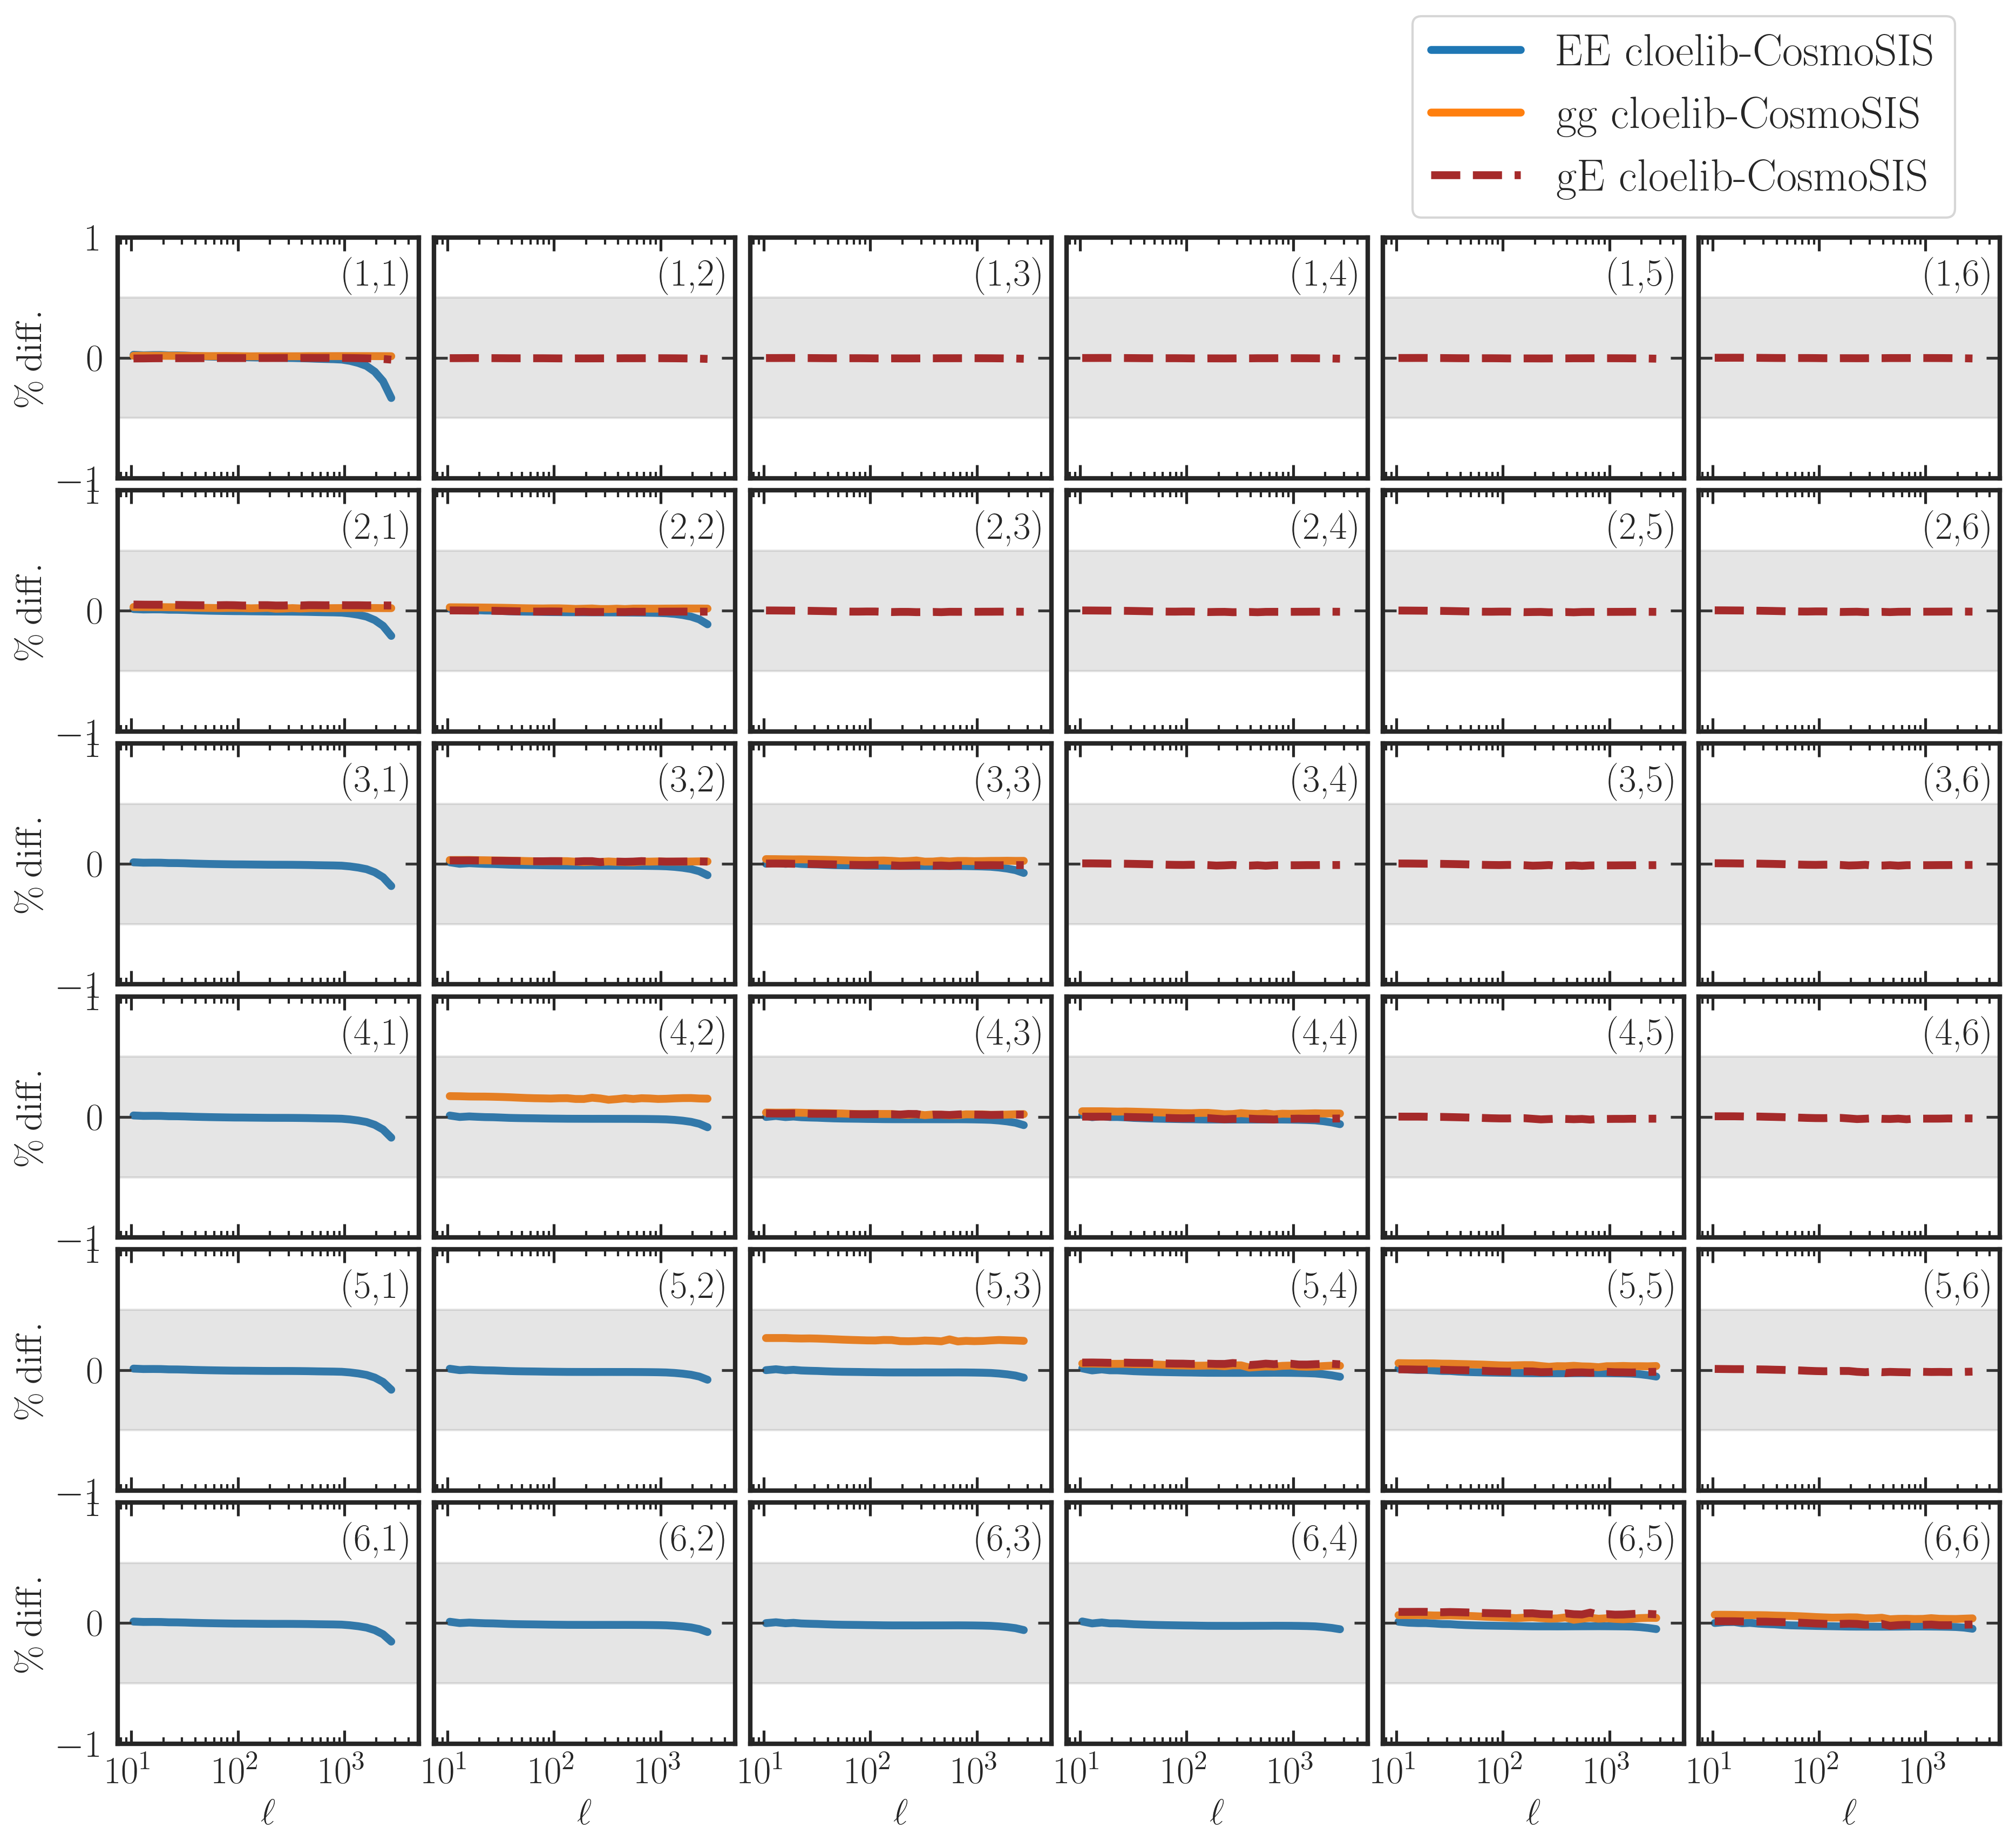

In [161]:
fig, axs = plt.subplots(6, 6, figsize=(15,12), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

lw = 3.5
for i in range(6):
    for j in range(6):
        if i>=j:
            axs[i, j].plot(ells_cosmosis, (cells_EE_cloe[('SHE', 'SHE',j+1 , i+1)][0,0] - cells_EE_cosmosis[:, i, j])/cells_EE_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:blue', label='EE cloelib-CosmoSIS', zorder=0)
            axs[i, j].plot(ells_cosmosis, (cells_gg_cloe[('POS', 'POS',j+1 , i+1)][:] - cells_gg_cosmosis[:, i, j])/cells_gg_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:orange', label='gg cloelib-CosmoSIS', zorder=1)
            axs[i, j].plot(ells_cosmosis, (cells_gE_cloe[('POS', 'SHE',i+1 , j+1)][0] - cells_gE_cosmosis[:, i, j])/cells_gE_cosmosis[:, i, j]*100, lw=lw, ls='--', color='brown', label='gE cloelib-CosmoSIS', zorder=2)
        else:
            axs[i, j].plot(ells_cosmosis, (cells_gE_cloe[('POS', 'SHE',i+1 , j+1)][0] - cells_gE_cosmosis[:, i, j])/cells_gE_cosmosis[:, i, j]*100, lw=lw, ls='--', color='brown', label='gE cloelib-CosmoSIS', zorder=2)
        axs[i,j].set_xscale('log')
        axs[i,0].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=16)
        axs[-1,j].set_xlabel(r'$\ell$', fontsize=16)
        axs[i,j].set_ylim([-1, 1])
        axs[i,j].fill_between(np.linspace(0, 10000, 10), -.5, .5, alpha=.2, color='grey')
        axs[i,j].set_xlim([0, 5e3])
        axs[i,j].text(0.75, 0.8, f'({i+1},{j+1})', transform=axs[i,j].transAxes, fontsize=17)


axs[0,0].legend(loc='center', bbox_to_anchor=(5.2, 1.5), fontsize=20)


plt.show()       

## 4. Coupled angular spectra


### 4.1. `CosmoSIS`

In [154]:
ells_cosmosis = np.loadtxt(path_cosmosis + 'pseudo-cells/shear_cl/ell.txt')
pseudo_cells_EE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
pseudo_cells_gg_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))
pseudo_cells_gE_cosmosis = np.zeros((len(ells_cosmosis), 6, 6))

# The Limber prefactor is now already multiplied in CosmoSIS files
for i in range(6):
    for j in range (6):
        if i>=j:
            pseudo_cells_EE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'pseudo-cells/shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))
            pseudo_cells_gg_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'pseudo-cells/galaxy_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))
            pseudo_cells_gE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'pseudo-cells/galaxy_shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))
        else:
            pseudo_cells_gE_cosmosis[:,i,j] = np.loadtxt(path_cosmosis + 'pseudo-cells/galaxy_shear_cl/bin_%s_%s.txt'%(str(i+1), str(j+1)))


### 4.2. `cloelib` 

In [155]:
# Read mixing matrices
mm = el.photo.mixing_matrices(path_cosmosis + 'MM.fits')

In [156]:
# CLOELIB PSEUDO Cls
nl = 100 # not used but need to pass (!)
ells_cloe = mm[('SHE', 'SHE', 1, 1)].ell
pseudo_cells_EE_cloe = twopoint_sheshe.get_pseudo_Cl(nl, ks, mm)
pseudo_cells_gg_cloe = twopoint_pospos.get_pseudo_Cl(nl, ks, mm)
pseudo_cells_gE_cloe = twopoint_posshe.get_pseudo_Cl(nl, ks, mm)

### 4.3. Compare angular power spectra

Note there is still some work to do on GC and GGL at large scales 

/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/354038447.py:23: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  axs[i,j].set_xlim([0, 5e3])
/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/354038447.py:14: RuntimeWarning: divide by zero encountered in divide
  axs[i, j].plot(ells_cosmosis, (pseudo_cells_gg_cloe[('POS', 'POS',j+1 , i+1)][:] - pseudo_cells_gg_cosmosis[:, i, j])/pseudo_cells_gg_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:orange', label='gg coupled-Cls cloelib-CosmoSIS', zorder=1)
/var/folders/sn/dlnv8hvd09bcvdv3gn6b16880000gn/T/ipykernel_1342/354038447.py:14: RuntimeWarning: invalid value encountered in divide
  axs[i, j].plot(ells_cosmosis, (pseudo_cells_gg_cloe[('POS', 'POS',j+1 , i+1)][:] - pseudo_cells_gg_cosmosis[:, i, j])/pseudo_cells_gg_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:orange', label='gg coupled-Cls cloelib-CosmoSIS', zorder=1)


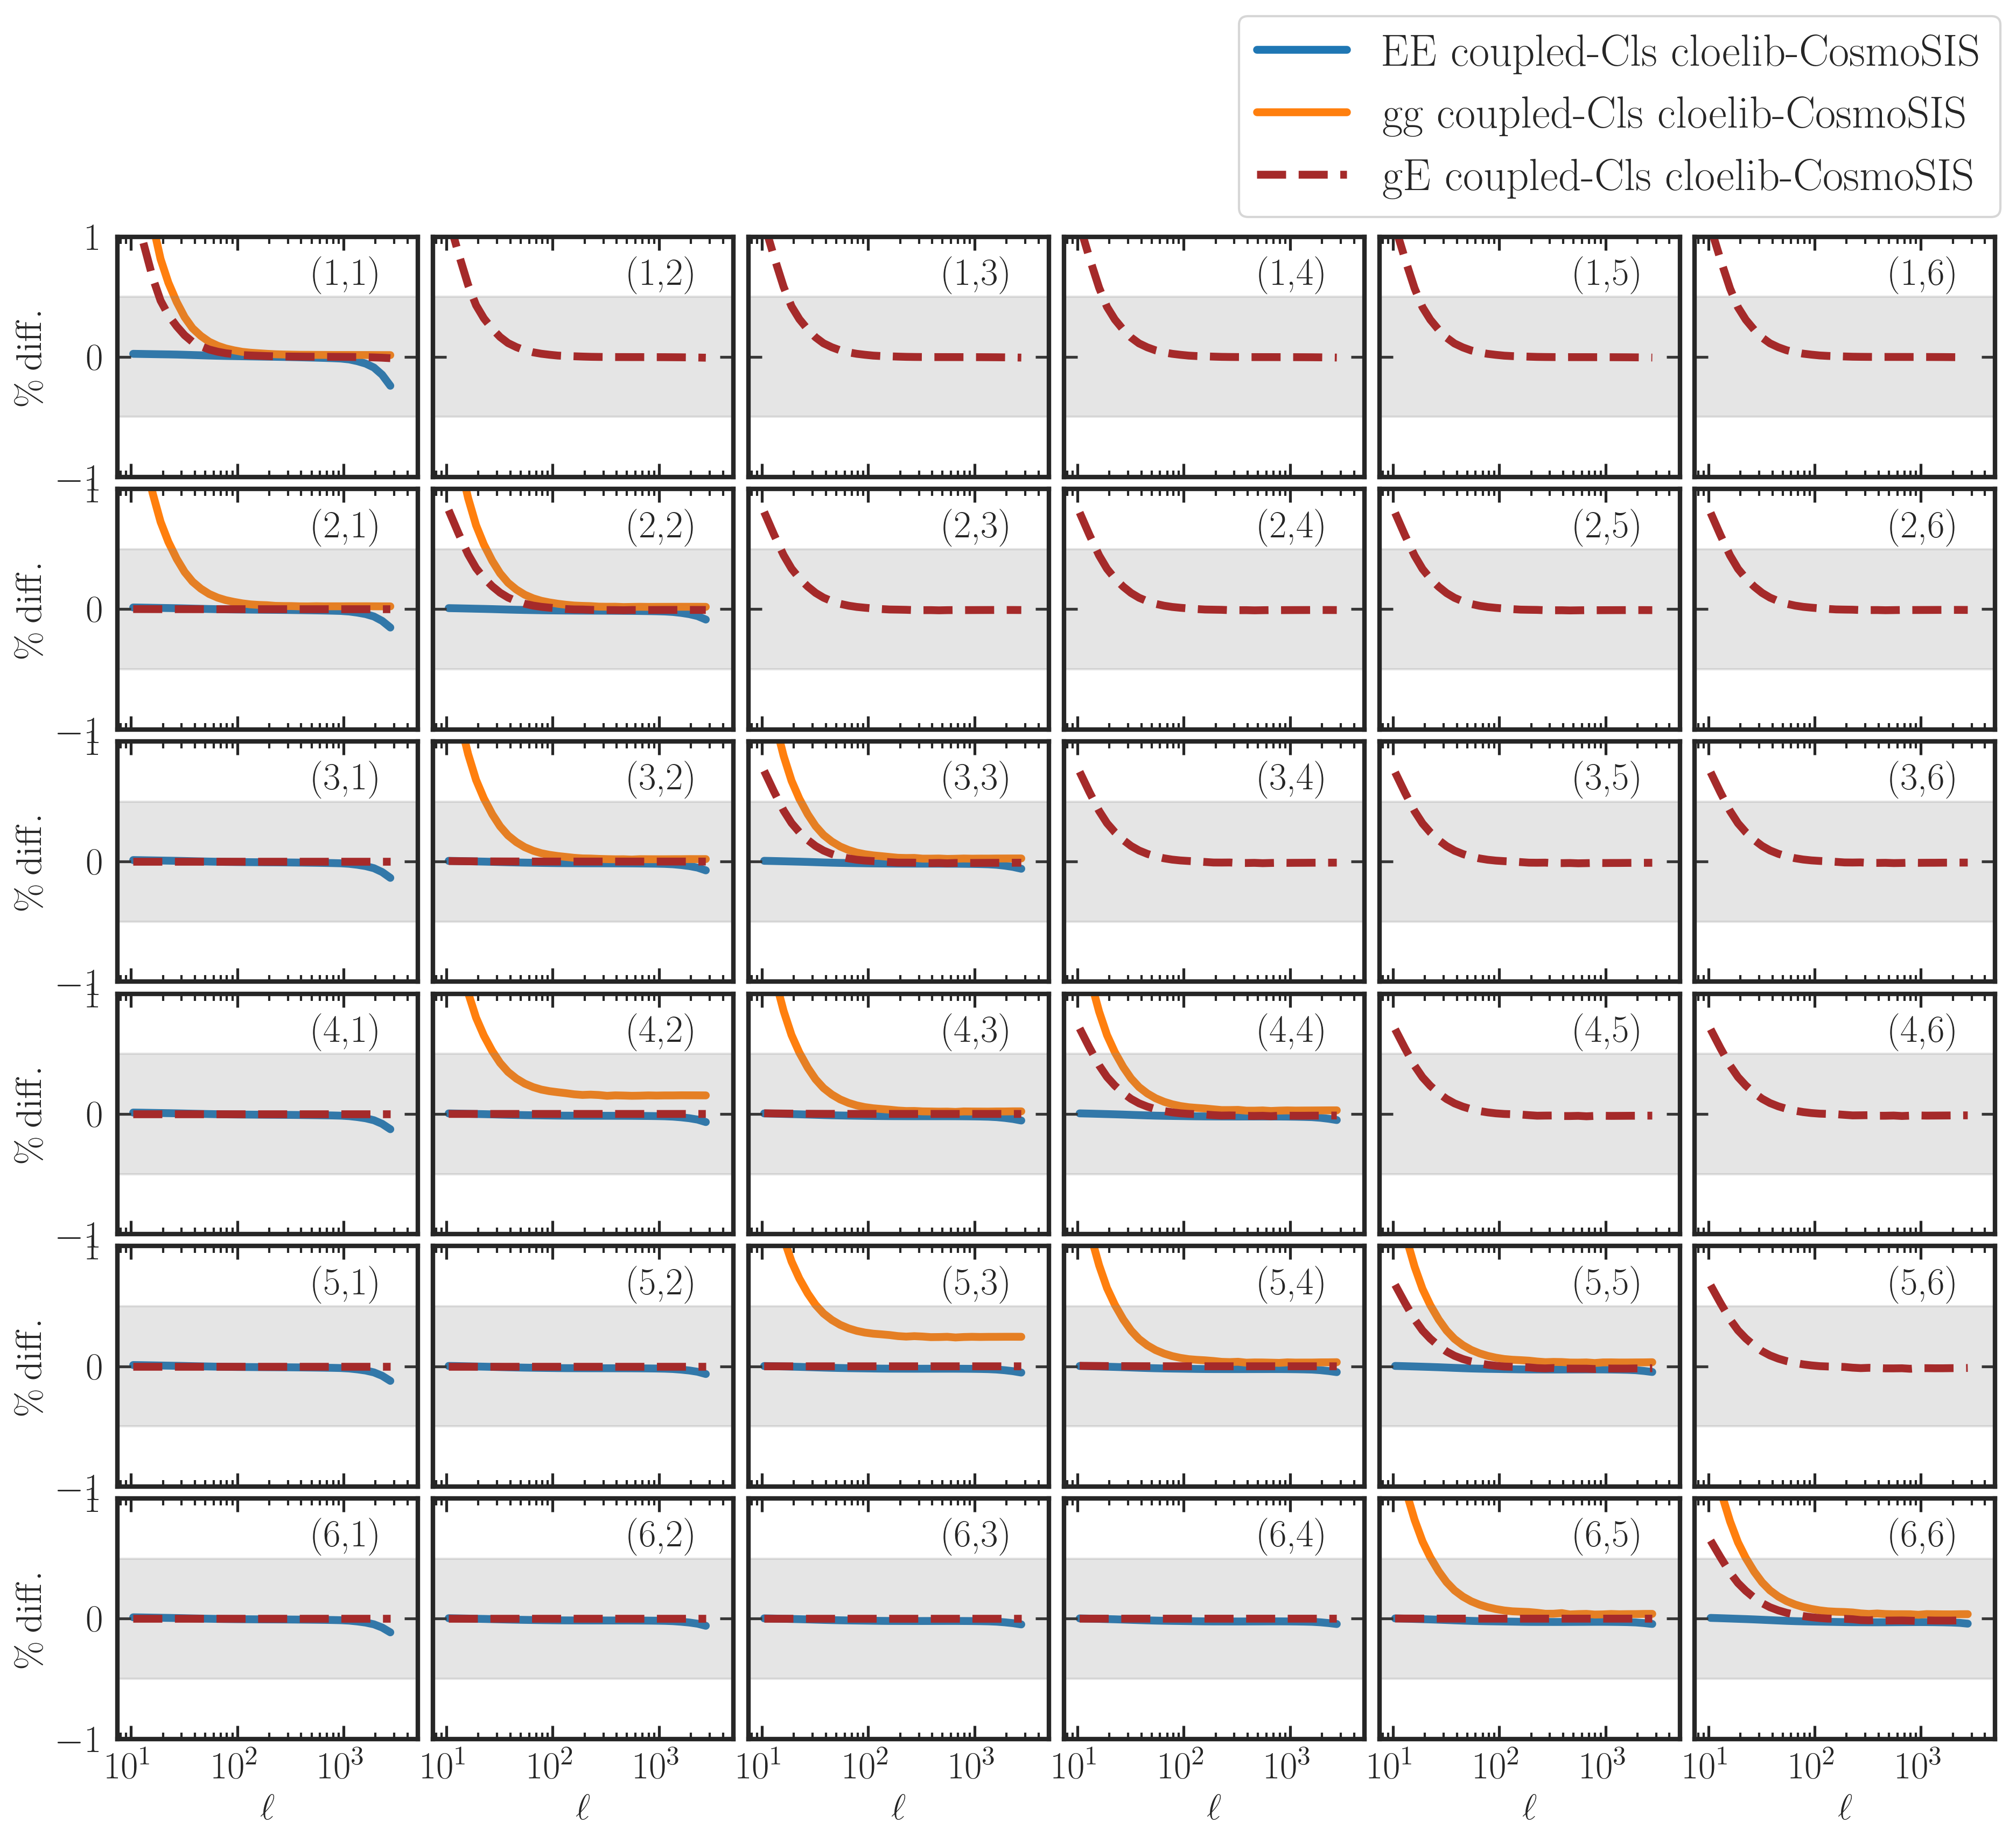

In [157]:
fig, axs = plt.subplots(6, 6, figsize=(15,12), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.05, hspace=0.05)

lw = 3.5
for i in range(6):
    for j in range(6):
        if i>=j:
            axs[i, j].plot(ells_cosmosis, (pseudo_cells_EE_cloe[('SHE', 'SHE',j+1 , i+1)][0,0] - pseudo_cells_EE_cosmosis[:, i, j])/pseudo_cells_EE_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:blue', label='EE coupled-Cls cloelib-CosmoSIS', zorder=0)
            axs[i, j].plot(ells_cosmosis, (pseudo_cells_gg_cloe[('POS', 'POS',j+1 , i+1)][:] - pseudo_cells_gg_cosmosis[:, i, j])/pseudo_cells_gg_cosmosis[:, i, j]*100, lw=lw, ls='-', color='tab:orange', label='gg coupled-Cls cloelib-CosmoSIS', zorder=1)
            axs[i, j].plot(ells_cosmosis, (pseudo_cells_gE_cloe[('POS', 'SHE',i+1 , j+1)][0] - pseudo_cells_gE_cosmosis[:, i, j])/pseudo_cells_gE_cosmosis[:, j, i]*100, lw=lw, ls='--', color='brown', label='gE coupled-Cls cloelib-CosmoSIS', zorder=2)
        else:
            axs[i, j].plot(ells_cosmosis, (pseudo_cells_gE_cloe[('POS', 'SHE',i+1 , j+1)][0] - pseudo_cells_gE_cosmosis[:, i, j] )/pseudo_cells_gE_cosmosis[:, i, j]*100, lw=lw, ls='--', color='brown', label='gE coupled-Cls cloelib-CosmoSIS', zorder=2)
        axs[i,j].set_xscale('log')
        axs[i,0].set_ylabel(r'$\% \: \rm{diff.}$', fontsize=16)
        axs[-1,j].set_xlabel(r'$\ell$', fontsize=16)
        axs[i,j].set_ylim([-1, 1])
        axs[i,j].fill_between(np.linspace(0, 10000, 10), -.5, .5, alpha=.2, color='grey')
        axs[i,j].set_xlim([0, 5e3])
        axs[i,j].text(0.65, 0.8, f'({i+1},{j+1})', transform=axs[i,j].transAxes, fontsize=17)


axs[0,0].legend(loc='center', bbox_to_anchor=(5, 1.5), fontsize=20)


plt.show()       